In [3]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.b import b_Model
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 12
       }

plt.rcParams['axes.grid'] = True

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=12) 
matplotlib.rc('ytick', labelsize=12) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
    
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
def set_init(init_v_):
    init_vars = aln.init_vars
    for i in range(len(init_vars)):
        if aln.params[init_vars[i]].size == 1:
            aln.params[init_vars[i]][0] = init_v_[i]
        else:
            aln.params[init_vars[i]][0,-1] = init_v_[i]
            
def setparams():
    
    aln.params.mue_ext_mean = 0.
    aln.params.mui_ext_mean = 0.
    
    aln.params.sigmae_ext = 0.
    aln.params.sigmai_ext = 0.
    
    aln.params.ext_exc_current = 0.
    aln.params.ext_inh_current = 0.
    
    # NO ADAPTATION
    aln.params.IA_init = np.array([0.])
    aln.params.a = 0.
    aln.params.b = 0.
    
    aln.params.di = 0.0
    aln.params.de = 0.0
    aln.params.signalV = 0.

def diff_control(diff_):
    d_int = 0.
    for n in range(diff_.shape[0]):
        for v in range(diff_.shape[1]):
            for t in range(diff_.shape[2]):
                d_int += np.abs(diff_[n,v,t]) * aln.params.dt
    return d_int

In [5]:
rates_exc_init = np.array( [[15. ]] )
rates_inh_init = np.array( [[15. ]] )
mufe_init = np.array( [[1. ]] )  # mV/ms
mufi_init = np.array( [[1. ]] )  # mV/ms
IA_init = np.array( [[0. ]] )  # pA
seem_init = np.array( [[0.0 * 0.5 ]] )
seim_init = np.array( [[0.0 * 0.5 ]] )   
seev_init = np.array( [[0.00 * 0.5 ]] )
seiv_init = np.array( [[0.00 * 0.5 ]] )
siim_init = np.array( [[0.0 * 0.5 ]] )
siem_init = np.array( [[0.0 * 0.5 ]] )
siiv_init = np.array( [[0.00 * 0.5 ]] )
siev_init = np.array( [[0.00 * 0.5 ]] )
mue_ou = np.array( [[0. ]] )
mui_ou = np.array( [[0. ]] )

initvars = np.array( [
rates_exc_init,
rates_inh_init,
mufe_init,
mufi_init,
IA_init,
seem_init ,
seim_init,
seev_init,
seiv_init,
siim_init,
siem_init,
siiv_init,
siev_init,
mue_ou,
mui_ou
    ])

max delay =  0


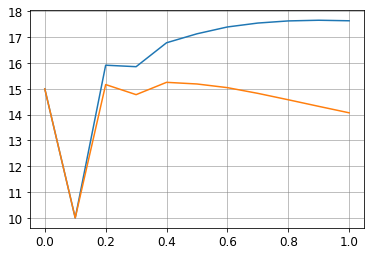

In [6]:
aln = b_Model()
setparams()
set_init(initvars)
aln.params['duration'] = 1.

control0 = aln.getZeroControl()
#control0 = step_control(maxI_ = 1.)

maxDelay = aln.getMaxDelay()
print("max delay = ", maxDelay)

aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

output = aln.output_vars
    
state_vars = aln.state_vars
init_vars = aln.init_vars

In [7]:
dur_pre = 0.
dur_post = 0.

max_it = 1
tol = 1e-16

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])


In [10]:
#setparams()

dur = 1.
aln.params.duration = dur

aln.params.sigmae_ext = 0.
aln.params.sigmai_ext = 0.
    
aln.params.ext_exc_current = 0.
aln.params.ext_inh_current = 0.

target = aln.getZeroTarget()

s_range = np.arange(0., 5., 1.)
print(s_range)

control1 = aln.getZeroControl()
control1[0,1,8] += 1.
control2 = aln.getZeroControl()

max_cntrl = 50. * 5.
start_step = 1e3
cost_params = [1.0, 0.0, 0.0]
cost.setParams(cost_params[0], cost_params[1], cost_params[2])
max_it = 20

improve = np.zeros( (len(s_range), len(s_range)) )
diff = np.zeros( (len(s_range), len(s_range)) )

for s_exc in range(len(s_range)):
    for s_inh in range(len(s_range)):
        print("---------------------------------------")
        print(s_exc, s_inh)
        aln.params.sigmae_ext = s_range[s_exc]
        aln.params.sigmai_ext = s_range[s_inh]
        set_init(initvars)

        aln.run(control=control1)

        target[:,0,:] = aln.state["rates_exc"][0,:]
        target[:,1,:] = aln.state["rates_inh"][0,:]   

        set_init(initvars)

        A1_bestControl, A1_bestState, A1_cost, runtime = aln.A1(control2, target, c_scheme, u_mat,
            u_scheme, max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            variables_ = [0])
        
        improve[s_exc, s_inh] = A1_cost[-1]/A1_cost[0]
        diff[s_exc, s_inh] = diff_control(A1_bestControl-control1)

[0. 1. 2. 3. 4.]
set cost params
---------------------------------------
0 0
True 0
RUN  0 , total integrated cost =  0.00030512370621797193
RUN  1 , total integrated cost =  0.0001648471459221836
RUN  2 , total integrated cost =  8.509128953527252e-05
RUN  3 , total integrated cost =  4.565278245007425e-05
RUN  4 , total integrated cost =  2.728168727947027e-05
RUN  5 , total integrated cost =  1.7671497437319875e-05
RUN  6 , total integrated cost =  9.13129260870015e-06
RUN  7 , total integrated cost =  4.882271488661842e-06
RUN  8 , total integrated cost =  3.186168990581866e-06
RUN  9 , total integrated cost =  2.064035324114126e-06
RUN  10 , total integrated cost =  1.1273539048261064e-06
RUN  11 , total integrated cost =  6.558248989737241e-07
RUN  12 , total integrated cost =  4.1013807197174154e-07
RUN  13 , total integrated cost =  2.6616307809986396e-07
RUN  14 , total integrated cost =  1.5018015962680256e-07
RUN  15 , total integrated cost =  8.189024054641809e-08
RUN  16 ,

D:\Promotion\neurolib\neurolib\models\b\timeIntegration.py:547: RuntimeWarning: invalid value encountered in sqrt
  + sigmai_ext ** 2
ERROR:root:nan in model output!
D:\Promotion\neurolib\neurolib\models\b\timeIntegration.py:541: RuntimeWarning: invalid value encountered in sqrt
  + sigmae_ext ** 2
ERROR:root:nan in model output!


RUN  19 , total integrated cost =  1.0148668793142813e-09
RUN  20 , total integrated cost =  6.23766436702375e-10
Improved over  20  iterations by  99.9994505090556  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([7], dtype=int64)) 2.460440406256652e-06
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([8], dtype=int64)) -1.8835788161569496e-06
---------------------------------------
0 2
True 0
RUN  0 , total integrated cost =  2.5207744984398106e-05
RUN  1 , total integrated cost =  1.5389773905863406e-05
RUN  2 , total integrated cost =  1.065348063428386e-05
RUN  3 , total integrated cost =  7.89331296197422e-06
too small start step, increase to  1000000.0
error
RUN  4 , total integrated cost =  5.152443718582197e-06
RUN  5 , total integrated cost =  3.690582585814698e-06
too small start step, increase to  1000000.0
error
RUN  6 , total integrated cost =  2.8055643193567577e-06


ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!


RUN  17 , total integrated cost =  2.077164244125337e-08
RUN  18 , total integrated cost =  1.2653287457728553e-08
RUN  19 , total integrated cost =  7.794615570835907e-09
RUN  20 , total integrated cost =  5.657479929037707e-09
Improved over  20  iterations by  99.99583290406568  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64)) 8.54451257577572e-06
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([8], dtype=int64)) -5.734375068406922e-06
---------------------------------------
1 1
True 0
RUN  0 , total integrated cost =  4.6530687726659736e-05
RUN  1 , total integrated cost =  2.746071789538794e-05
RUN  2 , total integrated cost =  1.3057940159199096e-05
RUN  3 , total integrated cost =  7.976094003803024e-06
too small start step, increase to  1000000.0
error
error
RUN  4 , total integrated cost =  4.367285821341067e-06
RUN  5 , total integrated cost =  2.6510406

...

ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!
ERROR:root:nan in model output!



too small start step, increase to  1000000.0
RUN  16 , total integrated cost =  1.2066876337059725e-08
too small start step, increase to  1000000.0
RUN  17 , total integrated cost =  1.1376105731968391e-08
too small start step, increase to  1000000.0
RUN  18 , total integrated cost =  1.1006664289396932e-08
too small start step, increase to  1000000.0
RUN  19 , total integrated cost =  1.0658493107081808e-08
too small start step, increase to  1000000.0
RUN  20 , total integrated cost =  1.0067740851860887e-08
Improved over  20  iterations by  76.63226897143727  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([5], dtype=int64)) 1.5765481760686796e-08
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([8], dtype=int64)) -3.248597096909354e-07
---------------------------------------
4 0
True 0
RUN  0 , total integrated cost =  1.1636508535384582e-05
RUN  1 , total integrated cost =  6.

ERROR:root:nan in model output!
ERROR:root:nan in model output!


 4 , total integrated cost =  1.913205561310055e-06
RUN  5 , total integrated cost =  1.4015008140035438e-06
too small start step, increase to  1000000.0
error
RUN  6 , total integrated cost =  1.0011414322564542e-06
RUN  7 , total integrated cost =  7.243613072247349e-07
too small start step, increase to  1000000.0
error
RUN  8 , total integrated cost =  5.470220478698329e-07
RUN  9 , total integrated cost =  4.197463557208677e-07
too small start step, increase to  1000000.0
RUN  10 , total integrated cost =  3.0555662753369877e-07
RUN  11 , total integrated cost =  2.2583165164813628e-07
too small start step, increase to  1000000.0
RUN  12 , total integrated cost =  1.7431578155767276e-07
RUN  13 , total integrated cost =  1.3805226313362082e-07
too small start step, increase to  1000000.0
RUN  14 , total integrated cost =  9.993246246272605e-08
RUN  15 , total integrated cost =  7.42957286588326e-08
too small start step, increase to  1000000.0
RUN  16 , total integrated cost =  5.85

too small start step, increase to  1000000.0
RUN  4 , total integrated cost =  1.4691955283855334e-08
too small start step, increase to  1000000.0
RUN  5 , total integrated cost =  1.4330068954310883e-08
too small start step, increase to  1000000.0
RUN  6 , total integrated cost =  1.3841822387179427e-08
too small start step, increase to  1000000.0
RUN  7 , total integrated cost =  1.3398512489528805e-08
too small start step, increase to  1000000.0
RUN  8 , total integrated cost =  1.3081932122017797e-08
too small start step, increase to  1000000.0
RUN  9 , total integrated cost =  1.2761405686992644e-08
too small start step, increase to  1000000.0
RUN  10 , total integrated cost =  1.2400138031358989e-08
too small start step, increase to  1000000.0
RUN  11 , total integrated cost =  1.2073496293823323e-08
too small start step, increase to  1000000.0
RUN  12 , total integrated cost =  1.1782021269554715e-08
too small start step, increase to  1000000.0
RUN  13 , total integrated cost = 

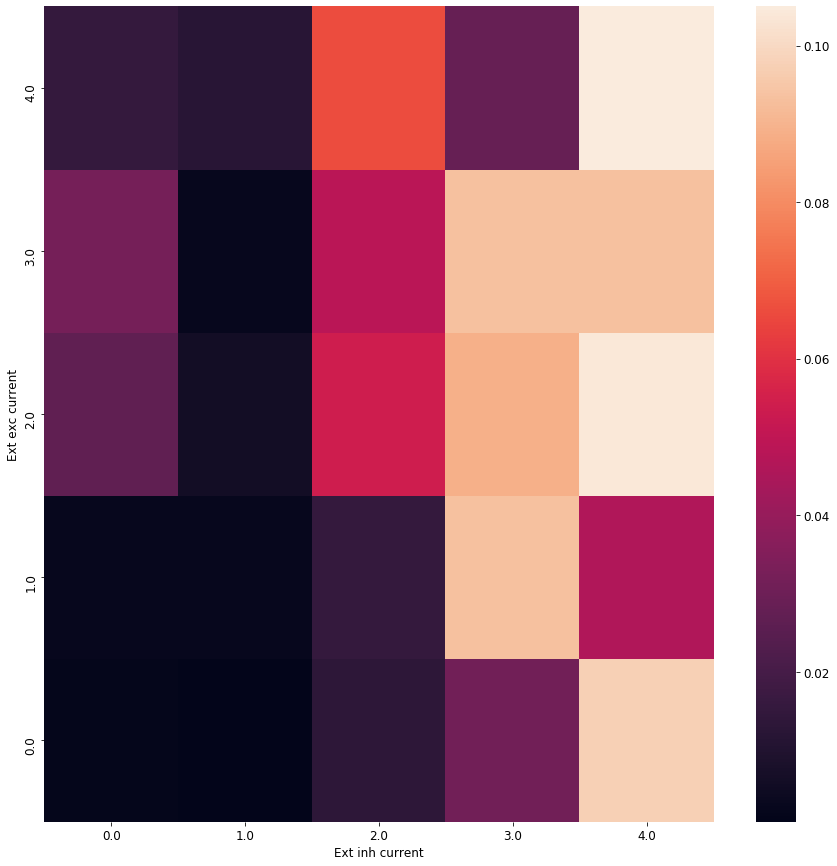

In [12]:
import seaborn as sns

x_axis_labels = s_range
y_axis_labels = s_range

fig, ax = plt.subplots(figsize=(15,15))
ax = sns.heatmap(diff, xticklabels=x_axis_labels, yticklabels=y_axis_labels)
ax.set_ylabel('Ext exc current')
ax.set_xlabel('Ext inh current')
ax.invert_yaxis()